In [2]:
import pandas as pd

In [3]:
import seaborn as sns

In [4]:
df = pd.read_csv("thyroid_dataset.csv")

In [5]:
df.shape

(6916, 22)

In [6]:
df.sample(10)

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
6379,0.65,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0.00002,39.0000,133.0,123.0,108.0,n
3912,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00170,0.0200,71.0,93.0,76.0,n
3002,0.72,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00130,0.0201,96.0,66.0,145.0,n
6678,0.67,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00220,0.0200,99.0,96.0,103.0,n
5087,0.44,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00041,8.0000,105.0,82.0,127.0,n
4756,0.64,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00044,25.0000,89.0,97.0,92.0,n
356,0.31,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00390,0.0201,106.0,115.0,93.0,n
1179,0.78,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00320,11.0000,126.0,89.0,142.0,n
3764,0.26,0,0,0,0,0,0,0,0,0,...,0,0,0,0,2.00000,0.0206,137.0,163.0,84.0,n
4370,0.30,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00060,32.0000,123.0,129.0,96.0,n


In [7]:
y = df["Outlier_label"]
df = df.drop("Outlier_label",axis=1)


In [8]:
from sklearn.preprocessing import StandardScaler

scrl_ =StandardScaler()

x = scrl_.fit_transform(df)

In [9]:
y.shape

(6916,)

<Axes: >

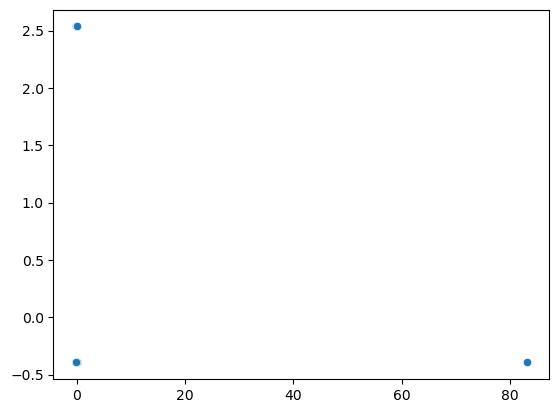

In [10]:
sns.scatterplot(x=x[:,0],y=x[:,2])

In [11]:
from sklearn.ensemble import IsolationForest

ise_ = IsolationForest(n_estimators=200,random_state=42,contamination='auto')
label = ise_.fit_predict(x)


In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2,random_state=42,)

x_pca = pca.fit_transform(x)


In [13]:
x.shape

(6916, 21)

<Axes: >

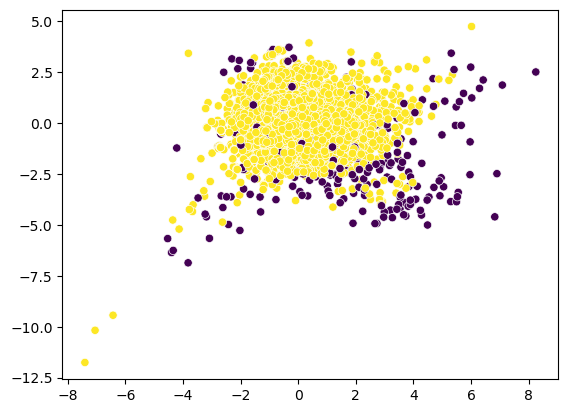

In [14]:
sns.scatterplot(x=x_pca[:,0],y=x_pca[:,1],c = label)

In [15]:
outlier = label.sum(where= label ==-1 )
norml =  label.sum(where= label == 1 )
print("outlier :",outlier,"normal : ",norml)

outlier : -270 normal :  6646


In [29]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=3,contamination=0.0361)

lof_label = lof.fit_predict(x)


c:\Users\jinju\anaconda3\Lib\site-packages\sklearn\neighbors\_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


In [30]:
outlier = lof_label.sum(where= lof_label==-1 )
norml =  lof_label.sum(where= lof_label == 1 )
print("outlier :",outlier,"normal : ",norml)

outlier : -250 normal :  6666


<Axes: >

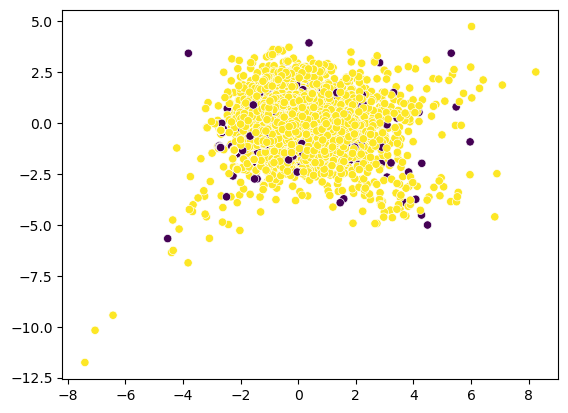

In [31]:
sns.scatterplot(x=x_pca[:,0],y=x_pca[:,1],c = lof_label)